In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect(':memory:')

In [2]:
from google.colab import files
uploaded = files.upload()


Saving archive.zip to archive.zip


In [4]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/mnt/data/extracted')

In [5]:
import os
print(os.listdir('/mnt/data/extracted'))

['treatments.csv', 'billing.csv', 'appointments.csv', 'doctors.csv', 'patients.csv']


In [6]:
patients = pd.read_csv('/mnt/data/extracted/patients.csv')
doctors = pd.read_csv('/mnt/data/extracted/doctors.csv')
appointments = pd.read_csv('/mnt/data/extracted/appointments.csv')
treatments = pd.read_csv('/mnt/data/extracted/treatments.csv')
billing = pd.read_csv('/mnt/data/extracted/billing.csv')

In [7]:
patients.to_sql('patients', conn, index=False, if_exists='replace')
doctors.to_sql('doctors', conn, index=False, if_exists='replace')
appointments.to_sql('appointments', conn, index=False, if_exists='replace')
treatments.to_sql('treatments', conn, index=False, if_exists='replace')
billing.to_sql('billing', conn, index=False, if_exists='replace')

200

In [8]:
pd.read_sql("SELECT COUNT(*) as total_patients FROM patients", conn)

,total_patients
0,50


In [9]:
pd.read_sql("SELECT COUNT(*) as total_appointments FROM appointments", conn)

,total_appointments
0,200


In [10]:
pd.read_sql("""
SELECT p.first_name, p.last_name, a.appointment_date
FROM patients p
JOIN appointments a
ON p.patient_id = a.patient_id
""", conn)

,first_name,last_name,appointment_date
0,David,Williams,2023-01-16
1,David,Williams,2023-01-26
2,David,Williams,2023-04-01
3,David,Williams,2023-04-09
4,Emily,Smith,2023-01-20
...,...,...,...
195,David,Moore,2023-12-26
196,Laura,Wilson,2023-03-27
197,Laura,Wilson,2023-05-06
198,Laura,Wilson,2023-06-29


In [12]:
pd.read_sql("""
SELECT d.first_name || ' ' || d.last_name AS doctor_name,
       COUNT(*) as total_appointments
FROM appointments a
JOIN doctors d
ON a.doctor_id = d.doctor_id
GROUP BY doctor_name
ORDER BY total_appointments DESC
""", conn)

,doctor_name,total_appointments
0,Sarah Taylor,29
1,David Taylor,25
2,Alex Davis,24
3,Jane Smith,22
4,Jane Davis,21
5,Linda Wilson,19
6,Sarah Smith,17
7,Linda Brown,16
8,David Jones,14
9,Robert Davis,13


In [13]:
pd.read_sql("""
SELECT p.first_name, p.last_name, SUM(b.amount) as total_bill
FROM billing b
JOIN patients p
ON b.patient_id = p.patient_id
GROUP BY p.patient_id
ORDER BY total_bill DESC
""", conn)

,first_name,last_name,total_bill
0,Laura,Davis,30053.08
1,David,Moore,23554.06
2,Michael,Taylor,22967.94
3,Michael,Wilson,21583.56
4,Robert,Wilson,19513.17
5,David,Wilson,18609.91
6,David,Wilson,18407.42
7,Emily,Miller,17082.48
8,Michael,Taylor,15929.15
9,Jane,Jones,14850.28


In [16]:
pd.read_sql("PRAGMA table_info(treatments);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,treatment_id,TEXT,0,None,0
1,1,appointment_id,TEXT,0,None,0
2,2,treatment_type,TEXT,0,None,0
3,3,description,TEXT,0,None,0
4,4,cost,REAL,0,None,0
5,5,treatment_date,TEXT,0,None,0


In [17]:
pd.read_sql("SELECT * FROM treatments LIMIT 5", conn)

,treatment_id,appointment_id,treatment_type,description,cost,treatment_date
0,T001,A001,Chemotherapy,Basic screening,3941.97,2023-08-09
1,T002,A002,MRI,Advanced protocol,4158.44,2023-06-09
2,T003,A003,MRI,Standard procedure,3731.55,2023-06-28
3,T004,A004,MRI,Basic screening,4799.86,2023-09-01
4,T005,A005,ECG,Standard procedure,582.05,2023-07-06


In [18]:
pd.read_sql("""
SELECT treatment_type, COUNT(*) as count
FROM treatments
GROUP BY treatment_type
ORDER BY count DESC
""", conn)

,treatment_type,count
0,Chemotherapy,49
1,X-Ray,41
2,ECG,38
3,Physiotherapy,36
4,MRI,36


In [19]:
pd.read_sql("""
SELECT * FROM billing
WHERE amount > (SELECT AVG(amount) FROM billing)
""", conn)

,bill_id,patient_id,treatment_id,bill_date,amount,payment_method,payment_status
0,B001,P034,T001,2023-08-09,3941.97,Insurance,Pending
1,B002,P032,T002,2023-06-09,4158.44,Insurance,Paid
2,B003,P048,T003,2023-06-28,3731.55,Insurance,Paid
3,B004,P025,T004,2023-09-01,4799.86,Insurance,Failed
4,B008,P016,T008,2023-05-24,3413.64,Cash,Failed
...,...,...,...,...,...,...,...
98,B191,P037,T191,2023-04-12,2972.88,Credit Card,Failed
99,B192,P038,T192,2023-08-31,4846.20,Insurance,Paid
100,B195,P048,T195,2023-08-19,2777.64,Credit Card,Failed
101,B198,P022,T198,2023-05-15,3383.72,Cash,Failed


In [20]:
pd.read_sql("""
SELECT
patient_id,
amount,
RANK() OVER (ORDER BY amount DESC) as rank
FROM billing
""", conn)

,patient_id,amount,rank
0,P024,4973.63,1
1,P017,4966.18,2
2,P021,4964.71,3
3,P050,4960.65,4
4,P044,4945.03,5
...,...,...,...
195,P019,662.72,196
196,P002,616.15,197
197,P037,606.37,198
198,P040,582.05,199


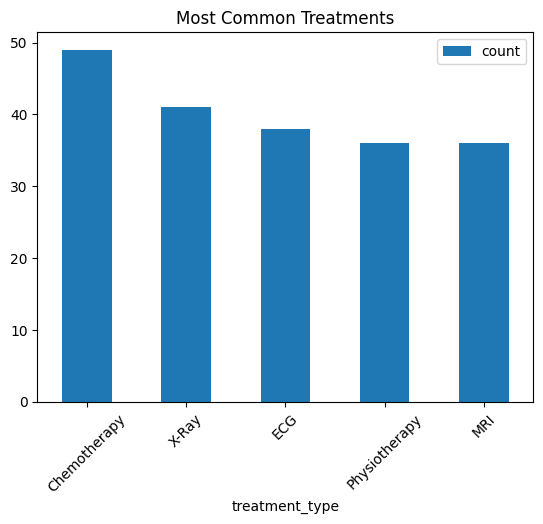

In [23]:
import matplotlib.pyplot as plt

df1 = pd.read_sql("""
SELECT treatment_type, COUNT(*) as count
FROM treatments
GROUP BY treatment_type
ORDER BY count DESC
""", conn)

df1.plot(x='treatment_type', y='count', kind='bar')
plt.xticks(rotation=45)
plt.title("Most Common Treatments")
plt.show()

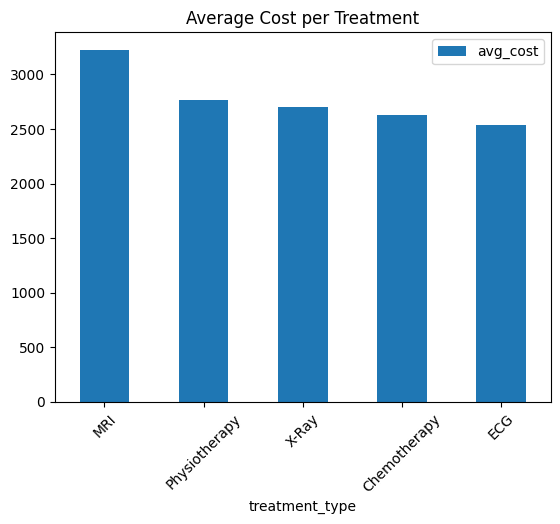

In [24]:
df2 = pd.read_sql("""
SELECT treatment_type, AVG(cost) as avg_cost
FROM treatments
GROUP BY treatment_type
ORDER BY avg_cost DESC
""", conn)

df2.plot(x='treatment_type', y='avg_cost', kind='bar')
plt.xticks(rotation=45)
plt.title("Average Cost per Treatment")
plt.show()

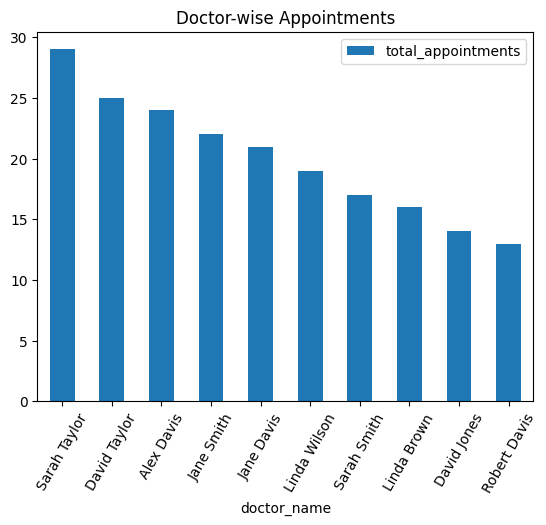

In [25]:
df3 = pd.read_sql("""
SELECT d.first_name || ' ' || d.last_name AS doctor_name,
       COUNT(*) as total_appointments
FROM appointments a
JOIN doctors d
ON a.doctor_id = d.doctor_id
GROUP BY doctor_name
ORDER BY total_appointments DESC
""", conn)

df3.plot(x='doctor_name', y='total_appointments', kind='bar')
plt.xticks(rotation=60)
plt.title("Doctor-wise Appointments")
plt.show()